# ARIMA and SES Benchmark for Bitcoin Volatility

This notebook builds simple benchmark models for **next-day Bitcoin realized volatility**.

The target is daily realized volatility:

**RV_t = sqrt(sum of squared 5-minute log returns during day t)**

For forecasting, we predict: **RV_{t+1}**

So the model uses data available up to one day and predicts volatility on the next day.

## Setup

In [17]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
import matplotlib.dates as mdates

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.options.display.float_format = "{:,.6f}".format

In [18]:
RAW_5MIN_PATH = Path("data/BTC/BTC_USD_coinbase_spot_5min.csv")
DAILY_FEATURES_PATH = Path("data/BTC/BTC_USD_coinbase_spot_daily_features.csv")

## Build the Volatility Series

The 5-minute file is used to calculate realized volatility. The daily feature file is used only to keep the same daily dates and the same train/test split as the rest of the project.

In [19]:
raw_5min = pd.read_csv(RAW_5MIN_PATH, parse_dates=["timestamp_utc"])
raw_5min = raw_5min.sort_values("timestamp_utc").set_index("timestamp_utc")

raw_5min["log_return_5min"] = np.log(raw_5min["close"]).diff()
raw_5min["squared_return_5min"] = raw_5min["log_return_5min"] ** 2

daily_rv = raw_5min["squared_return_5min"].resample("1D").sum().pow(0.5)
daily_rv = daily_rv.rename("realized_volatility")

daily_split = pd.read_csv(
    DAILY_FEATURES_PATH,
    parse_dates=["timestamp_utc"],
    usecols=["timestamp_utc", "split"],
).set_index("timestamp_utc").sort_index()

volatility_data = daily_split.join(daily_rv, how="left").dropna()
volatility_data["realized_volatility_pct"] = volatility_data["realized_volatility"] * 100
volatility_data["target_realized_volatility_next"] = volatility_data["realized_volatility"].shift(-1)

volatility_data.head()

,split,realized_volatility,realized_volatility_pct,target_realized_volatility_next
timestamp_utc,,,,
2016-05-14 00:00:00+00:00,train,0.007552,0.755233,0.006824
2016-05-15 00:00:00+00:00,train,0.006824,0.682375,0.011054
2016-05-16 00:00:00+00:00,train,0.011054,1.105422,0.011140
2016-05-17 00:00:00+00:00,train,0.011140,1.114000,0.008932
2016-05-18 00:00:00+00:00,train,0.008932,0.893241,0.022536


In [20]:
train = volatility_data.loc[volatility_data["split"] == "train", "realized_volatility"]
test = volatility_data.loc[volatility_data["split"] == "test", "realized_volatility"]

print(f"Train rows: {len(train):,}")
print(f"Test rows: {len(test):,}")
print(f"Train period: {train.index.min().date()} to {train.index.max().date()}")
print(f"Test period: {test.index.min().date()} to {test.index.max().date()}")

Train rows: 2,876
Test rows: 719
Train period: 2016-05-14 to 2024-04-21
Test period: 2024-04-22 to 2026-04-11


In [21]:
volatility_data.groupby("split")["realized_volatility_pct"].describe()

,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,719.000000,2.296374,1.070814,0.502083,1.602402,2.138968,2.738443,11.381480
train,"2,876.000000",3.409476,2.568381,0.309584,1.846068,2.773835,4.127415,32.919344


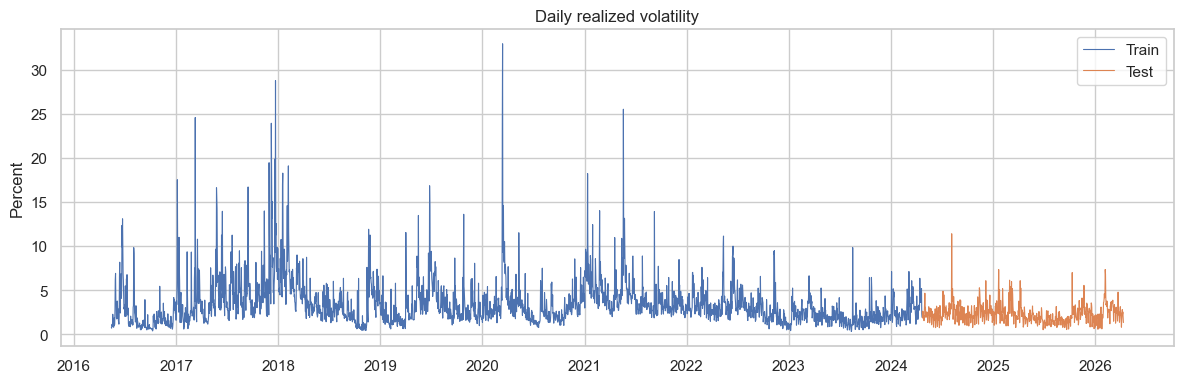

In [22]:
plt.figure(figsize=(12, 4))
plt.plot(train.index, train * 100, label="Train", linewidth=0.8)
plt.plot(test.index, test * 100, label="Test", linewidth=0.8)
plt.title("Daily realized volatility")
plt.ylabel("Percent")
plt.legend()
plt.tight_layout()
plt.show()

## Simple Benchmark Forecasts

Before ARIMA and SES, we create simple benchmarks:

- `naive`: tomorrow volatility equals today volatility,
- `rolling_7`, `rolling_14`, `rolling_30`: mean volatility from the last days.

During the test period we use walk-forward evaluation. After each day, the true value becomes available and is added to the history.

In [23]:
history = list(train.to_numpy(dtype=float))
baseline_rows = []

for date, actual in test.items():
    baseline_rows.append({
        "timestamp_utc": date,
        "actual": float(actual),
        "naive": history[-1],
        "rolling_7": float(np.mean(history[-7:])),
        "rolling_14": float(np.mean(history[-14:])),
        "rolling_30": float(np.mean(history[-30:])),
    })
    history.append(float(actual))

forecasts = pd.DataFrame(baseline_rows).set_index("timestamp_utc")
forecasts.head()

,actual,naive,rolling_7,rolling_14,rolling_30
timestamp_utc,,,,,
2024-04-22 00:00:00+00:00,0.026065,0.019099,0.035592,0.036049,0.030309
2024-04-23 00:00:00+00:00,0.018315,0.026065,0.034136,0.036070,0.030241
2024-04-24 00:00:00+00:00,0.025664,0.018315,0.031036,0.035391,0.029895
2024-04-25 00:00:00+00:00,0.024716,0.025664,0.028630,0.034863,0.029737
2024-04-26 00:00:00+00:00,0.021196,0.024716,0.026978,0.034678,0.029582


## SES Benchmark

Simple Exponential Smoothing is a classical model for a series with no clear trend. The smoothing parameter `alpha` is selected automatically on the training set.

In [24]:
ses_model = SimpleExpSmoothing(
    train.to_numpy(dtype=float),
    initialization_method="estimated",
).fit(optimized=True)

ses_alpha = float(ses_model.params["smoothing_level"])
ses_level = float(ses_model.level[-1])
ses_forecasts = []

for actual in test.to_numpy(dtype=float):
    ses_forecasts.append(ses_level)
    ses_level = ses_alpha * float(actual) + (1 - ses_alpha) * ses_level

forecasts["ses"] = np.maximum(ses_forecasts, 0)

print(f"SES alpha: {ses_alpha:.6f}")

SES alpha: 0.419064


## ARIMA Order Selection

ARIMA is tuned on the training set only. We test small values of `p`, `d`, and `q`, then select the model with the lowest AIC.

In [25]:
order_rows = []

for d in [0, 1]:
    for p in range(6):
        for q in range(6):
            trend_options = ["n", "c"] if d == 0 else ["n"]
            for trend in trend_options:
                try:
                    model = ARIMA(
                        train.to_numpy(dtype=float),
                        order=(p, d, q),
                        trend=trend,
                        enforce_stationarity=False,
                        enforce_invertibility=False,
                    )
                    result = model.fit()
                    order_rows.append({
                        "p": p,
                        "d": d,
                        "q": q,
                        "trend": trend,
                        "aic": float(result.aic),
                        "bic": float(result.bic),
                    })
                except Exception:
                    pass

order_search = pd.DataFrame(order_rows).sort_values("aic")
order_search.head(10)

,p,d,q,trend,aic,bic
27,2,0,1,c,"-14,706.073795","-14,676.256495"
29,2,0,2,c,"-14,698.759692","-14,662.981020"
39,3,0,1,c,"-14,698.611698","-14,662.833026"
67,5,0,3,c,"-14,692.316691","-14,632.692534"
41,3,0,2,c,"-14,690.904368","-14,649.162584"
43,3,0,3,c,"-14,688.816580","-14,641.114468"
55,4,0,3,c,"-14,688.325774","-14,634.660898"
19,1,0,3,c,"-14,688.080998","-14,652.304414"
17,1,0,2,c,"-14,687.175451","-14,657.359890"
57,4,0,4,c,"-14,686.885247","-14,627.261090"


In [26]:
best_order = order_search.iloc[0]
best_p = int(best_order["p"])
best_d = int(best_order["d"])
best_q = int(best_order["q"])
best_trend = str(best_order["trend"])

arima_model = ARIMA(
    train.to_numpy(dtype=float),
    order=(best_p, best_d, best_q),
    trend=best_trend,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
arima_result = arima_model.fit()

print(f"Selected ARIMA({best_p}, {best_d}, {best_q}), trend={best_trend}")
print(f"AIC: {best_order['aic']:.6f}")
print(f"BIC: {best_order['bic']:.6f}")

Selected ARIMA(2, 0, 1), trend=c
AIC: -14706.073795
BIC: -14676.256495


## ARIMA Walk-Forward Forecasts

The ARIMA model is fitted on the training set. Then we forecast one day ahead. After the true test value is known, we update the model state without refitting parameters.

In [27]:
state = arima_result
arima_forecasts = []

for actual in test.to_numpy(dtype=float):
    arima_forecasts.append(float(state.forecast(steps=1)[0]))
    state = state.append([float(actual)], refit=False)

forecasts["arima"] = np.maximum(arima_forecasts, 0)
forecasts.head()

,actual,naive,rolling_7,rolling_14,rolling_30,ses,arima
timestamp_utc,,,,,,,
2024-04-22 00:00:00+00:00,0.026065,0.019099,0.035592,0.036049,0.030309,0.028680,0.027661
2024-04-23 00:00:00+00:00,0.018315,0.026065,0.034136,0.036070,0.030241,0.027584,0.030103
2024-04-24 00:00:00+00:00,0.025664,0.018315,0.031036,0.035391,0.029895,0.023700,0.025779
2024-04-25 00:00:00+00:00,0.024716,0.025664,0.028630,0.034863,0.029737,0.024523,0.028605
2024-04-26 00:00:00+00:00,0.021196,0.024716,0.026978,0.034678,0.029582,0.024604,0.027855


## ARIMA Residual Diagnostics

Before comparing the models, we check ARIMA residuals on the training set. If residuals still have strong autocorrelation, ARIMA did not fully capture the time pattern in volatility.

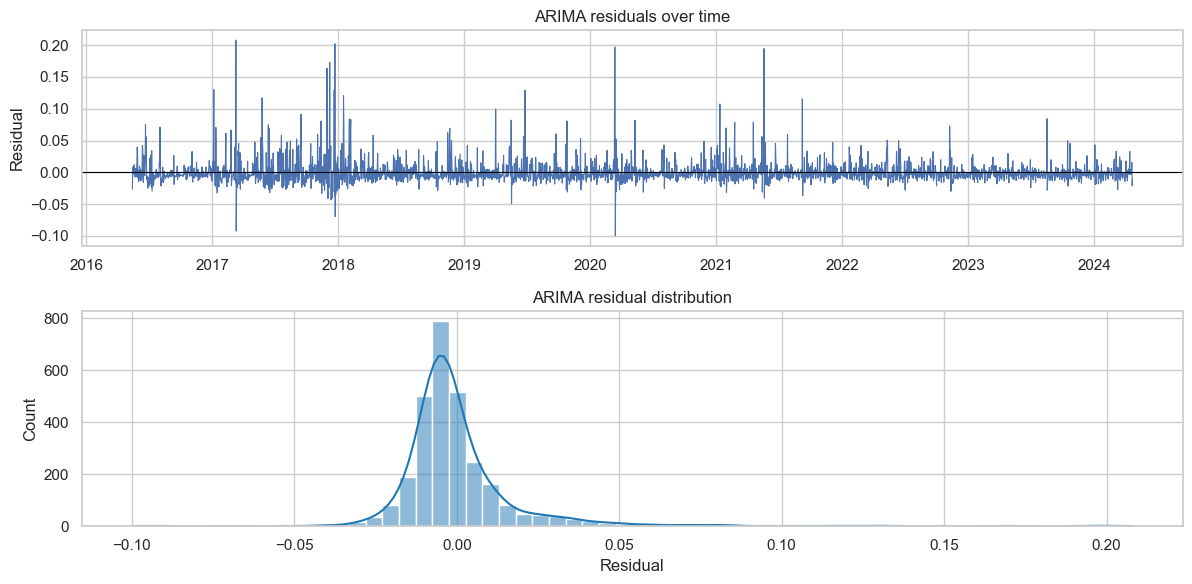

In [28]:
arima_residuals = pd.Series(arima_result.resid, index=train.index).dropna()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=False)

axes[0].plot(arima_residuals.index, arima_residuals, linewidth=0.8)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("ARIMA residuals over time")
axes[0].set_ylabel("Residual")

sns.histplot(arima_residuals, bins=60, kde=True, ax=axes[1], color="tab:blue")
axes[1].set_title("ARIMA residual distribution")
axes[1].set_xlabel("Residual")

plt.tight_layout()
plt.show()

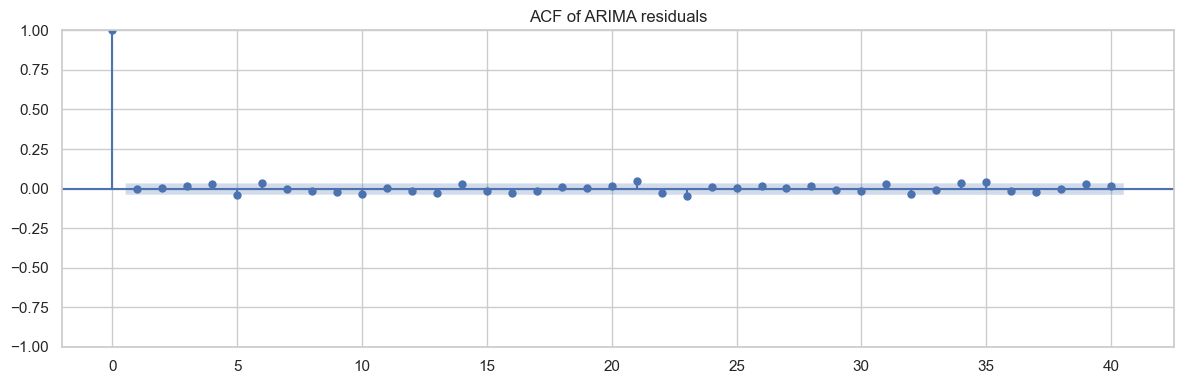

In [29]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(arima_residuals, lags=40, ax=ax)
ax.set_title("ACF of ARIMA residuals")
plt.tight_layout()
plt.show()

In [30]:
ljung_box_residuals = acorr_ljungbox(
    arima_residuals,
    lags=[5, 10, 20],
    return_df=True,
)
ljung_box_residuals.index.name = "lag"
ljung_box_residuals

,lb_stat,lb_pvalue
lag,,
5,8.025161,0.154854
10,18.033074,0.054408
20,27.966294,0.110200


## Benchmark Results

The main metrics are MAE and RMSE. Lower values are better.

Direction accuracy checks if the model correctly predicts whether volatility goes up or down compared with the previous day.

Forecasts are clipped at zero, because volatility cannot be negative.

In [31]:
previous_actual = np.concatenate([[train.iloc[-1]], test.iloc[:-1].to_numpy(dtype=float)])
actual = forecasts["actual"].to_numpy(dtype=float)

metric_rows = []
for model_name in ["naive", "rolling_7", "rolling_14", "rolling_30", "ses", "arima"]:
    prediction = forecasts[model_name].to_numpy(dtype=float)
    error = prediction - actual
    denominator = np.abs(actual) + np.abs(prediction)
    smape = np.mean(np.where(denominator == 0, 0, 2 * np.abs(error) / denominator)) * 100

    if np.std(prediction) > 0 and np.std(actual) > 0:
        correlation = float(np.corrcoef(actual, prediction)[0, 1])
    else:
        correlation = np.nan

    metric_rows.append({
        "model": model_name,
        "mae": float(np.mean(np.abs(error))),
        "rmse": float(np.sqrt(np.mean(error ** 2))),
        "mape_pct": float(np.mean(np.abs(error / actual)) * 100),
        "smape_pct": float(smape),
        "correlation": correlation,
        "direction_accuracy": float(np.mean((prediction - previous_actual >= 0) == (actual - previous_actual >= 0))),
    })

metrics = pd.DataFrame(metric_rows).sort_values("rmse")
metrics

,model,mae,rmse,mape_pct,smape_pct,correlation,direction_accuracy
5,arima,0.006508,0.009188,36.136540,28.367115,0.541413,0.614743
4,ses,0.006660,0.009469,34.584555,29.313261,0.516080,0.649513
1,rolling_7,0.006632,0.009543,34.102281,28.910532,0.486667,0.673157
2,rolling_14,0.006999,0.010115,36.311472,30.194287,0.384160,0.664812
3,rolling_30,0.007113,0.010334,37.902888,30.938622,0.309881,0.643950
0,naive,0.007234,0.010519,36.087620,31.809404,0.516567,0.504868


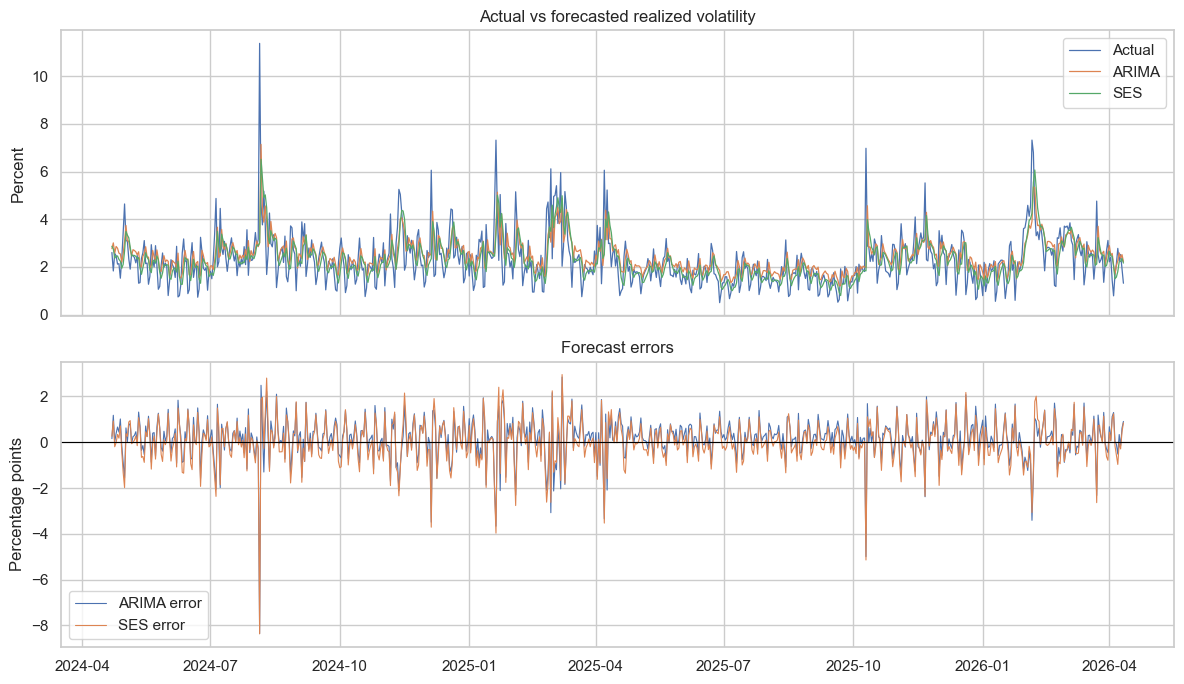

In [32]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(forecasts.index, forecasts["actual"] * 100, label="Actual", linewidth=0.9)
axes[0].plot(forecasts.index, forecasts["arima"] * 100, label="ARIMA", linewidth=0.9)
axes[0].plot(forecasts.index, forecasts["ses"] * 100, label="SES", linewidth=0.9)
axes[0].set_title("Actual vs forecasted realized volatility")
axes[0].set_ylabel("Percent")
axes[0].legend()

axes[1].plot(forecasts.index, (forecasts["arima"] - forecasts["actual"]) * 100, label="ARIMA error", linewidth=0.8)
axes[1].plot(forecasts.index, (forecasts["ses"] - forecasts["actual"]) * 100, label="SES error", linewidth=0.8)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Forecast errors")
axes[1].set_ylabel("Percentage points")
axes[1].legend()

plt.tight_layout()
plt.show()

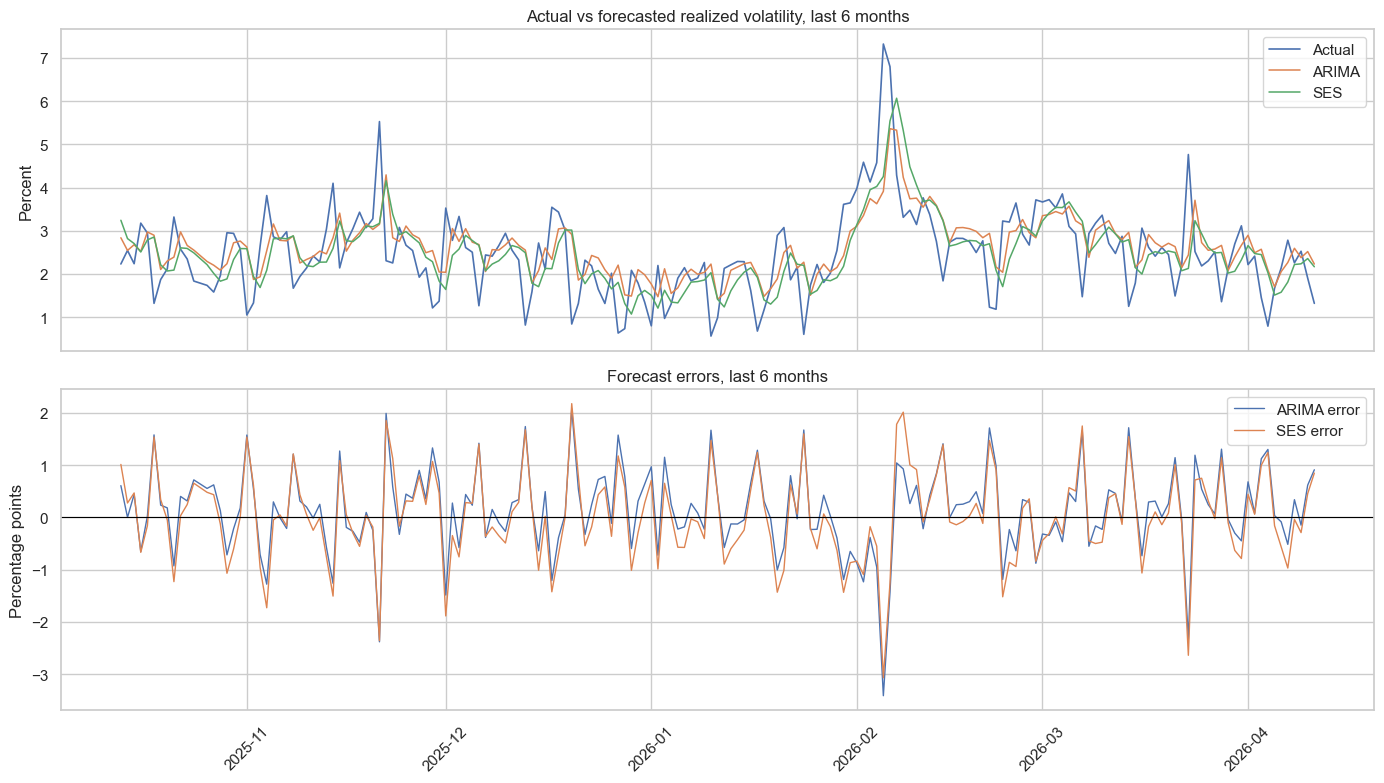

In [33]:
plot_df = forecasts.tail(180)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(plot_df.index, plot_df["actual"] * 100, label="Actual", linewidth=1.2)
axes[0].plot(plot_df.index, plot_df["arima"] * 100, label="ARIMA", linewidth=1.1)
axes[0].plot(plot_df.index, plot_df["ses"] * 100, label="SES", linewidth=1.1)
axes[0].set_title("Actual vs forecasted realized volatility, last 6 months")
axes[0].set_ylabel("Percent")
axes[0].legend()

axes[1].plot(plot_df.index, (plot_df["arima"] - plot_df["actual"]) * 100, label="ARIMA error", linewidth=1)
axes[1].plot(plot_df.index, (plot_df["ses"] - plot_df["actual"]) * 100, label="SES error", linewidth=1)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Forecast errors, last 6 months")
axes[1].set_ylabel("Percentage points")
axes[1].legend()

axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [34]:
best_model = metrics.iloc[0]
print(f"Best model by RMSE: {best_model['model']}")
print(f"RMSE: {best_model['rmse']:.6f}")
print(f"MAE: {best_model['mae']:.6f}")
print(f"Direction accuracy: {best_model['direction_accuracy']:.4f}")

Best model by RMSE: arima
RMSE: 0.009188
MAE: 0.006508
Direction accuracy: 0.6147


## Final Benchmark Summary

The table below is the final benchmark output from this notebook.

In [35]:
metrics

,model,mae,rmse,mape_pct,smape_pct,correlation,direction_accuracy
5,arima,0.006508,0.009188,36.136540,28.367115,0.541413,0.614743
4,ses,0.006660,0.009469,34.584555,29.313261,0.516080,0.649513
1,rolling_7,0.006632,0.009543,34.102281,28.910532,0.486667,0.673157
2,rolling_14,0.006999,0.010115,36.311472,30.194287,0.384160,0.664812
3,rolling_30,0.007113,0.010334,37.902888,30.938622,0.309881,0.643950
0,naive,0.007234,0.010519,36.087620,31.809404,0.516567,0.504868


## Summary

The best model in this benchmark is ARIMA(2,0,1) with a constant. It has the lowest RMSE and MAE on the test set, so it gives the most accurate point forecasts of next-day realized volatility among the tested classical models.

Simple Exponential Smoothing is close to ARIMA, but ARIMA performs slightly better in terms of RMSE. The rolling 7-day mean has the best direction accuracy, which means it is good at predicting whether volatility will go up or down, but it is not the best model for the exact volatility level.

Overall, the results show that next-day Bitcoin realized volatility has some predictable structure.